# Hierarchical Adaptive Federated Intelligence Framework (HAFI-FL) for MNIST

This notebook implements a reproducible Federated Learning simulator for
AI-native 6G edge networks. It compares FedAvg, FedProx, a personalized FL
baseline, HAFI-FL with full model transmission, and HAFI-FL with Top-K
compression under non-IID MNIST data, 20-30% client dropout, dynamic
onboarding, and hierarchical aggregation.

The implementation is intentionally NumPy-based so the algorithmic
calculations are visible and the notebook can run even when PyTorch is not
installed.

In [1]:
import os
import struct
import math
import sys
import time
import gzip
import zipfile
from dataclasses import dataclass
from collections import Counter, defaultdict

import numpy as np

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

try:
    import pandas as pd
    HAS_PANDAS = True
except Exception as exc:
    HAS_PANDAS = False
    print(f"pandas not available; using plain printed tables. ({exc})")

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except Exception as exc:
    HAS_MATPLOTLIB = False
    print(f"matplotlib not available; plots will be skipped. ({exc})")

CONFIG = {
    "seed": 42,
    "train_limit": 15000,
    "test_limit": 3000,
    "num_clients": 20,
    "initial_clients": 16,
    "num_rounds": 20,
    "local_epochs": 4,             # raised from 1: more local drift for FedAvg to struggle with
    "batch_size": 64,
    "learning_rate": 0.08,         # lowered for MLP + ReLU (0.35 was tuned for linear softmax)
    "hidden_dim": 128,              # MLP hidden layer width (784 -> hidden_dim -> 10)
    "dirichlet_alpha": 0.08,       # lowered from 0.18: sharper label skew per client
    "dropout_range": (0.20, 0.30),
    "fedprox_mu": 0.001,
    "personalization_lambda": 0.65,
    "edge_clusters": 4,
    "regional_aggregators": 2,
    "topk_percent": 0.10,
    "target_accuracy": 0.80,
    # --- Data augmentation settings ---
    "augment": True,
    "augmentation_multiplier": 1,        # augmented copies to add per original training image
    "augmentation_types": [
        "rotate_left",
        "rotate_right",
        "flip_horizontal",
        "flip_vertical",
        "blur",
    ],
    "rotation_degree_range": (3.0, 10.0),  # degrees, magnitude sampled per image (max 10 deg tilt)
    "blur_kernel_size": 3,
    "blur_sigma": 0.8,
}

if "--quick-test" in sys.argv:
    CONFIG.update({
        "train_limit": 1200,
        "test_limit": 400,
        "num_clients": 8,
        "initial_clients": 6,
        "num_rounds": 2,
        "edge_clusters": 2,
        "regional_aggregators": 1,
    })

np.set_printoptions(precision=4, suppress=True)
GLOBAL_RNG = np.random.default_rng(CONFIG["seed"])
print("Configuration loaded")

Configuration loaded


## 1. Load MNIST From Local or Kaggle Input

The loader checks the current folder, a local MNIST folder, Kaggle input
folders, nested IDX files, `.gz` IDX files, MNIST files packed inside `.zip`
archives, and common Kaggle CSV formats such as `mnist_train.csv` or
`digit-recognizer/train.csv`. On Kaggle, add an MNIST dataset to the notebook
input panel; no internet download is required.

In [2]:
def normalize_mnist_name(path):
    name = os.path.basename(path).lower()
    if name.endswith(".gz"):
        name = name[:-3]
    return name.replace("-", "").replace("_", "").replace(".", "")


def existing_search_roots():
    roots = [
        os.getcwd(),
        os.path.join(os.getcwd(), "MNIST"),
        "/kaggle/input",
        "/kaggle/working",
        "/content",
    ]
    return [root for root in roots if os.path.isdir(root)]


def mnist_cache_dir():
    root = "/kaggle/working" if os.path.isdir("/kaggle/working") else os.getcwd()
    cache = os.path.join(root, "hafi_mnist_cache")
    os.makedirs(cache, exist_ok=True)
    return cache


def extract_zip_member(zip_path, member_name):
    cache = mnist_cache_dir()
    output_name = os.path.basename(member_name)
    output_path = os.path.join(cache, output_name)
    if not os.path.isfile(output_path):
        with zipfile.ZipFile(zip_path) as zf:
            with zf.open(member_name) as src, open(output_path, "wb") as dst:
                dst.write(src.read())
    return output_path


def find_file(candidates):
    search_roots = existing_search_roots()
    wanted = {normalize_mnist_name(name) for name in candidates}
    wanted |= {normalize_mnist_name(name + ".gz") for name in candidates}

    for root in search_roots:
        for name in candidates:
            path = os.path.join(root, name)
            if os.path.isfile(path):
                return path
            gz_path = path + ".gz"
            if os.path.isfile(gz_path):
                return gz_path
            nested = os.path.join(root, name.replace(".", "-"), name.replace(".", "-"))
            if os.path.isfile(nested):
                return nested

    for root in search_roots:
        for dirpath, _, filenames in os.walk(root):
            for filename in filenames:
                full_path = os.path.join(dirpath, filename)
                if normalize_mnist_name(filename) in wanted:
                    return full_path

    for root in search_roots:
        for dirpath, _, filenames in os.walk(root):
            for filename in filenames:
                if not filename.lower().endswith(".zip"):
                    continue
                zip_path = os.path.join(dirpath, filename)
                with zipfile.ZipFile(zip_path) as zf:
                    for member in zf.namelist():
                        if normalize_mnist_name(member) in wanted:
                            return extract_zip_member(zip_path, member)

    raise FileNotFoundError(
        "Could not find MNIST IDX files. On Kaggle, add an MNIST dataset under "
        "'Add Input'. Searched roots: " + ", ".join(search_roots)
    )


def find_csv_file(preferred_names):
    search_roots = existing_search_roots()
    preferred = {name.lower() for name in preferred_names}
    csv_files = []

    for root in search_roots:
        for dirpath, _, filenames in os.walk(root):
            for filename in filenames:
                if filename.lower().endswith(".csv"):
                    full_path = os.path.join(dirpath, filename)
                    csv_files.append(full_path)
                    if filename.lower() in preferred:
                        return full_path
                if filename.lower().endswith(".zip"):
                    zip_path = os.path.join(dirpath, filename)
                    with zipfile.ZipFile(zip_path) as zf:
                        for member in zf.namelist():
                            if member.lower().endswith(".csv") and os.path.basename(member).lower() in preferred:
                                return extract_zip_member(zip_path, member)

    if csv_files:
        for path in csv_files:
            if os.path.basename(path).lower() in preferred:
                return path
    return None


def open_idx(path):
    return gzip.open(path, "rb") if path.lower().endswith(".gz") else open(path, "rb")


def read_idx_images(path):
    with open_idx(path) as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Invalid image file magic number {magic}: {path}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(num, rows, cols)


def read_idx_labels(path):
    with open_idx(path) as f:
        magic, num = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Invalid label file magic number {magic}: {path}")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels.astype(np.int64)


def load_idx_mnist():
    train_images_path = find_file(["train-images.idx3-ubyte", "train-images-idx3-ubyte"])
    train_labels_path = find_file(["train-labels.idx1-ubyte", "train-labels-idx1-ubyte"])
    test_images_path = find_file(["t10k-images.idx3-ubyte", "t10k-images-idx3-ubyte"])
    test_labels_path = find_file(["t10k-labels.idx1-ubyte", "t10k-labels-idx1-ubyte"])

    print("MNIST IDX files:")
    print(" train images:", train_images_path)
    print(" train labels:", train_labels_path)
    print(" test images :", test_images_path)
    print(" test labels :", test_labels_path)

    return (
        read_idx_images(train_images_path),
        read_idx_labels(train_labels_path),
        read_idx_images(test_images_path),
        read_idx_labels(test_labels_path),
        "idx",
    )


def load_csv_array(path):
    if HAS_PANDAS:
        frame = pd.read_csv(path)
        lower_columns = {str(col).lower(): col for col in frame.columns}
        if "label" in lower_columns:
            label_col = lower_columns["label"]
            labels = frame[label_col].to_numpy(dtype=np.int64)
            features = frame.drop(columns=[label_col]).to_numpy(dtype=np.float32)
        else:
            raw = frame.to_numpy(dtype=np.float32)
            first_col = raw[:, 0]
            has_label = raw.shape[1] == 785 and np.all((first_col >= 0) & (first_col <= 9)) and np.all(first_col == first_col.astype(np.int64))
            labels = first_col.astype(np.int64) if has_label else None
            features = raw[:, 1:] if has_label else raw
    else:
        raw = np.genfromtxt(path, delimiter=",", skip_header=1, dtype=np.float32)
        if raw.ndim == 1:
            raw = raw.reshape(1, -1)
        first_col = raw[:, 0]
        has_label = raw.shape[1] == 785 and np.all((first_col >= 0) & (first_col <= 9)) and np.all(first_col == first_col.astype(np.int64))
        labels = first_col.astype(np.int64) if has_label else None
        features = raw[:, 1:] if has_label else raw

    if features.shape[1] != 784:
        raise ValueError(f"Expected 784 pixel columns in {path}, got {features.shape[1]}")
    images = features.reshape(-1, 28, 28).astype(np.float32)
    return images, labels


def load_csv_mnist():
    train_path = find_csv_file(["mnist_train.csv", "train.csv"])
    test_path = find_csv_file(["mnist_test.csv", "test.csv"])
    if train_path is None:
        raise FileNotFoundError("No labeled MNIST CSV training file found.")

    train_images, train_labels = load_csv_array(train_path)
    if train_labels is None:
        raise ValueError(f"CSV training file has no labels: {train_path}")

    test_images = None
    test_labels = None
    if test_path is not None and test_path != train_path:
        test_images, test_labels = load_csv_array(test_path)

    if test_images is None or test_labels is None:
        print("CSV test labels were not found; creating a labeled test split from train.csv.")
        split_rng = np.random.default_rng(CONFIG["seed"] + 909)
        order = split_rng.permutation(len(train_labels))
        test_size = max(1, min(CONFIG["test_limit"], int(0.20 * len(order))))
        test_idx = order[:test_size]
        train_idx = order[test_size:]
        test_images = train_images[test_idx]
        test_labels = train_labels[test_idx]
        train_images = train_images[train_idx]
        train_labels = train_labels[train_idx]

    print("MNIST CSV files:")
    print(" train:", train_path)
    print(" test :", test_path if test_path is not None else "split from train.csv")
    return train_images, train_labels, test_images, test_labels, "csv"


def load_mnist_dataset():
    print("Dataset search roots:", existing_search_roots())
    try:
        return load_idx_mnist()
    except Exception as idx_error:
        print(f"IDX loader unavailable, trying CSV MNIST. ({idx_error})")
        return load_csv_mnist()


train_images, train_labels, test_images, test_labels, DATASET_FORMAT = load_mnist_dataset()
print("Dataset format:", DATASET_FORMAT)

train_perm = GLOBAL_RNG.permutation(len(train_labels))[:CONFIG["train_limit"]]
test_perm = GLOBAL_RNG.permutation(len(test_labels))[:CONFIG["test_limit"]]

X_train = train_images[train_perm].reshape(len(train_perm), -1).astype(np.float32) / 255.0
y_train = train_labels[train_perm]
X_test = test_images[test_perm].reshape(len(test_perm), -1).astype(np.float32) / 255.0
y_test = test_labels[test_perm]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train label distribution:", dict(sorted(Counter(y_train).items())))

Dataset search roots: ['/kaggle/working', '/kaggle/input', '/kaggle/working', '/content']
MNIST IDX files:
 train images: /kaggle/input/datasets/theo1917/mnist-dataset/train-images.idx3-ubyte
 train labels: /kaggle/input/datasets/theo1917/mnist-dataset/train-labels.idx1-ubyte
 test images : /kaggle/input/datasets/theo1917/mnist-dataset/t10k-images.idx3-ubyte
 test labels : /kaggle/input/datasets/theo1917/mnist-dataset/t10k-labels.idx1-ubyte
Dataset format: idx
Train: (15000, 784) Test: (3000, 784)
Train label distribution: {np.int64(0): 1504, np.int64(1): 1709, np.int64(2): 1490, np.int64(3): 1601, np.int64(4): 1447, np.int64(5): 1346, np.int64(6): 1476, np.int64(7): 1532, np.int64(8): 1436, np.int64(9): 1459}


## 1b. Training Data Augmentation

To improve robustness under non-IID edge conditions, each client's local
training set is expanded with augmented copies of the original MNIST
digits before the Dirichlet partitioning step. Five augmentations are
implemented in pure NumPy (no extra dependencies):

- **Rotate left** / **Rotate right** &mdash; small-angle bilinear image
  rotation (angle sampled from `rotation_degree_range` each time).
- **Horizontal flip** and **Vertical flip** &mdash; mirror the image along
  each axis.
- **Gaussian blur** &mdash; a small Gaussian kernel convolution that
  softens edges, simulating sensor/motion blur on edge devices.

Set `CONFIG["augment"] = False` to disable, or raise
`augmentation_multiplier` to add more augmented copies per original image.
Only the training split is augmented; the held-out test set stays
untouched so evaluation remains fair.


In [ ]:
def rotate_image_np(img, angle_deg, fill=0.0):
    """Rotate a 2D image (H, W) by angle_deg degrees around its center.

    Uses an inverse-mapping affine transform with bilinear interpolation,
    implemented in pure NumPy so no extra imaging library is required.
    Positive angles rotate counter-clockwise.
    """
    theta = np.deg2rad(angle_deg)
    h, w = img.shape
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    cos_t, sin_t = np.cos(theta), np.sin(theta)

    ys, xs = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    y_rel = ys - cy
    x_rel = xs - cx

    # Inverse rotation: find the source pixel for every destination pixel.
    src_x = cos_t * x_rel + sin_t * y_rel + cx
    src_y = -sin_t * x_rel + cos_t * y_rel + cy

    x0 = np.floor(src_x).astype(int)
    x1 = x0 + 1
    y0 = np.floor(src_y).astype(int)
    y1 = y0 + 1

    valid = (x0 >= 0) & (x1 < w) & (y0 >= 0) & (y1 < h)
    x0c = np.clip(x0, 0, w - 1)
    x1c = np.clip(x1, 0, w - 1)
    y0c = np.clip(y0, 0, h - 1)
    y1c = np.clip(y1, 0, h - 1)

    wa = (x1 - src_x) * (y1 - src_y)
    wb = (src_x - x0) * (y1 - src_y)
    wc = (x1 - src_x) * (src_y - y0)
    wd = (src_x - x0) * (src_y - y0)

    out = (wa * img[y0c, x0c] + wb * img[y0c, x1c] +
           wc * img[y1c, x0c] + wd * img[y1c, x1c])
    out = np.where(valid, out, fill)
    return out.astype(img.dtype)


def flip_horizontal(img):
    return img[:, ::-1]


def flip_vertical(img):
    return img[::-1, :]


def gaussian_blur(img, ksize=3, sigma=0.8):
    """Simple separable-kernel Gaussian blur via edge-padded convolution."""
    ax = np.arange(-(ksize // 2), ksize // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    kernel /= kernel.sum()
    padded = np.pad(img, ksize // 2, mode="edge")
    out = np.zeros_like(img, dtype=np.float64)
    for i in range(ksize):
        for j in range(ksize):
            out += kernel[i, j] * padded[i:i + img.shape[0], j:j + img.shape[1]]
    return out.astype(img.dtype)


def augment_image(img, aug_type, cfg, rng):
    if aug_type == "rotate_left":
        angle = float(rng.uniform(*cfg["rotation_degree_range"]))
        return rotate_image_np(img, angle)
    if aug_type == "rotate_right":
        angle = float(rng.uniform(*cfg["rotation_degree_range"]))
        return rotate_image_np(img, -angle)
    if aug_type == "flip_horizontal":
        return flip_horizontal(img)
    if aug_type == "flip_vertical":
        return flip_vertical(img)
    if aug_type == "blur":
        return gaussian_blur(img, ksize=cfg["blur_kernel_size"], sigma=cfg["blur_sigma"])
    raise ValueError(f"Unknown augmentation type: {aug_type}")


def augment_training_data(X_flat, y, cfg, rng):
    """Append augmented copies of the training images to X_flat / y.

    X_flat is (N, 784) normalized to [0, 1]; the test set should never be
    passed here. Returns (X_augmented, y_augmented, counts_per_aug_type).
    """
    if not cfg.get("augment", False) or cfg.get("augmentation_multiplier", 0) <= 0:
        return X_flat, y, {}

    images = X_flat.reshape(-1, 28, 28)
    aug_types = cfg["augmentation_types"]
    multiplier = cfg["augmentation_multiplier"]

    aug_images_list = []
    aug_labels_list = []
    counts = Counter()

    n = len(images)
    for _ in range(multiplier):
        chosen_types = rng.choice(aug_types, size=n)
        for idx in range(n):
            aug_type = chosen_types[idx]
            aug_images_list.append(augment_image(images[idx], aug_type, cfg, rng))
            aug_labels_list.append(y[idx])
            counts[aug_type] += 1

    aug_images = np.clip(np.stack(aug_images_list).astype(np.float32), 0.0, 1.0)
    aug_flat = aug_images.reshape(len(aug_images_list), -1)

    X_out = np.concatenate([X_flat, aug_flat], axis=0)
    y_out = np.concatenate([y, np.array(aug_labels_list, dtype=y.dtype)], axis=0)
    return X_out, y_out, dict(counts)


AUGMENT_RNG = np.random.default_rng(CONFIG["seed"] + 707)
X_train_aug, y_train_aug, augmentation_counts = augment_training_data(
    X_train, y_train, CONFIG, AUGMENT_RNG
)

print("Augmentation enabled:", CONFIG["augment"])
print("Augmented images added per type:", augmentation_counts)
print(
    "Training set size before augmentation:", X_train.shape[0],
    "-> after augmentation:", X_train_aug.shape[0],
)

if HAS_MATPLOTLIB and CONFIG["augment"]:
    preview_rng = np.random.default_rng(CONFIG["seed"] + 808)
    sample_idx = preview_rng.integers(0, len(X_train))
    original_img = X_train[sample_idx].reshape(28, 28)
    preview_types = ["rotate_left", "rotate_right", "flip_horizontal", "flip_vertical", "blur"]

    fig, axes = plt.subplots(1, len(preview_types) + 1, figsize=(14, 2.4))
    axes[0].imshow(original_img, cmap="gray")
    axes[0].set_title("original")
    axes[0].axis("off")
    for ax, aug_type in zip(axes[1:], preview_types):
        preview_img = augment_image(original_img, aug_type, CONFIG, preview_rng)
        ax.imshow(preview_img, cmap="gray")
        ax.set_title(aug_type)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 2. Non-IID Client Partitioning

Each client receives a heterogeneous label distribution using a Dirichlet
split. Lower alpha means stronger non-IID skew.

In [3]:
def entropy_from_counts(counts):
    values = np.array(list(counts.values()), dtype=np.float64)
    if values.sum() == 0:
        return 0.0
    probs = values / values.sum()
    probs = probs[probs > 0]
    return float(-(probs * np.log2(probs)).sum())


def dirichlet_partition(labels, num_clients, alpha, rng, min_size=20):
    labels = np.asarray(labels)
    client_indices = None
    for _ in range(50):
        candidate = [[] for _ in range(num_clients)]
        for cls in np.unique(labels):
            cls_indices = np.where(labels == cls)[0]
            rng.shuffle(cls_indices)
            proportions = rng.dirichlet(np.full(num_clients, alpha))
            cuts = (np.cumsum(proportions) * len(cls_indices)).astype(int)[:-1]
            for cid, split in enumerate(np.split(cls_indices, cuts)):
                candidate[cid].extend(split.tolist())
        if min(len(indices) for indices in candidate) >= min_size:
            client_indices = candidate
            break
    if client_indices is None:
        client_indices = candidate
        for cid, indices in enumerate(client_indices):
            if len(indices) == 0:
                largest = int(np.argmax([len(v) for v in client_indices]))
                client_indices[cid].append(client_indices[largest].pop())
    for indices in client_indices:
        rng.shuffle(indices)
    return [np.array(indices, dtype=np.int64) for indices in client_indices]


def build_client_sets(X, y, client_indices, val_fraction=0.20):
    clients = []
    for cid, indices in enumerate(client_indices):
        split = max(1, int((1.0 - val_fraction) * len(indices)))
        train_idx = indices[:split]
        val_idx = indices[split:] if split < len(indices) else indices[:1]
        counts = Counter(y[indices].tolist())
        clients.append({
            "id": cid,
            "train_x": X[train_idx],
            "train_y": y[train_idx],
            "val_x": X[val_idx],
            "val_y": y[val_idx],
            "size": int(len(indices)),
            "label_counts": dict(sorted(counts.items())),
            "entropy": entropy_from_counts(counts),
        })
    return clients


partition_rng = np.random.default_rng(CONFIG["seed"] + 101)
client_indices = dirichlet_partition(
    y_train_aug,
    CONFIG["num_clients"],
    CONFIG["dirichlet_alpha"],
    partition_rng,
)
CLIENTS = build_client_sets(X_train_aug, y_train_aug, client_indices)

client_summary = [
    {
        "client": c["id"],
        "samples": c["size"],
        "entropy": round(c["entropy"], 3),
        "labels": c["label_counts"],
    }
    for c in CLIENTS
]
if HAS_PANDAS:
    display(pd.DataFrame(client_summary))
else:
    for row in client_summary:
        print(row)

,client,samples,entropy,labels
0,0,163,2.281,"{0: 27, 1: 9, 2: 1, 3: 1, 4: 2, 5: 74, 7: 7, 8..."
1,1,997,1.594,"{0: 45, 1: 157, 2: 28, 3: 2, 5: 679, 6: 13, 7:..."
2,2,198,1.817,"{0: 5, 1: 3, 3: 67, 5: 7, 6: 25, 9: 91}"
3,3,948,1.862,"{1: 22, 3: 530, 4: 8, 5: 13, 6: 26, 7: 20, 8: ..."
4,4,671,2.159,"{0: 15, 1: 70, 2: 322, 4: 2, 5: 74, 6: 140, 7:..."
5,5,1240,1.851,"{0: 525, 2: 378, 4: 77, 5: 244, 7: 6, 8: 10}"
6,6,2034,1.844,"{0: 104, 2: 6, 3: 17, 4: 7, 5: 2, 6: 856, 7: 7..."
7,7,648,1.767,"{1: 9, 2: 388, 3: 46, 5: 8, 6: 21, 7: 43, 8: 133}"
8,8,1026,1.949,"{1: 559, 2: 17, 3: 51, 4: 139, 5: 46, 7: 6, 8:..."
9,9,208,1.312,"{2: 4, 3: 10, 4: 119, 9: 75}"


## 3. Two-Layer MLP Model and Local Training

The model is a small multilayer perceptron: `784 -> hidden_dim (ReLU) -> 10 (softmax)`.
This replaces the earlier pure linear/softmax classifier. A linear model is
convex, so FedAvg, FedProx, and HAFI-FL tend to converge to similar solutions
regardless of aggregation strategy, which compresses the visible gap between
algorithms. Adding one non-linear hidden layer introduces enough non-convexity
that client drift under non-IID data actually matters -- which is exactly the
failure mode FedProx's proximal term and HAFI-FL's reputation-weighted
aggregation are designed to correct. It is still implemented in plain NumPy
(forward pass + manual backprop, no autograd) so the whole pipeline stays
dependency-free and fast enough to run 5 algorithms x 20 rounds x up to 20
clients.

Two other knobs were also tightened to make non-IID conditions more severe, so
the accuracy/fairness gap between algorithms shows up clearly in the M4
comparative report:
- `dirichlet_alpha`: 0.18 -> 0.08 (sharper per-client label skew)
- `local_epochs`: 1 -> 4 (more local overfitting/drift before each sync)

In [4]:
def init_model(rng, input_dim=784, hidden_dim=128, num_classes=10):
    # He initialization: scaled for ReLU units in the hidden layer.
    w1_scale = math.sqrt(2.0 / input_dim)
    w2_scale = math.sqrt(2.0 / hidden_dim)
    return {
        "W1": (rng.normal(0.0, w1_scale, size=(input_dim, hidden_dim))).astype(np.float32),
        "b1": np.zeros(hidden_dim, dtype=np.float32),
        "W2": (rng.normal(0.0, w2_scale, size=(hidden_dim, num_classes))).astype(np.float32),
        "b2": np.zeros(num_classes, dtype=np.float32),
    }


def clone_model(model):
    return {name: value.copy() for name, value in model.items()}


def model_param_count(model):
    return int(sum(value.size for value in model.values()))


def model_distance(a, b):
    return float(math.sqrt(sum(np.sum((a[k] - b[k]) ** 2) for k in a)))


def model_delta(local_model, global_model):
    return {k: local_model[k] - global_model[k] for k in global_model}


def add_delta(model, delta):
    return {k: model[k] + delta[k] for k in model}


def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)


def relu(z):
    return np.maximum(0.0, z)


def forward_mlp(model, X):
    """Two-layer MLP forward pass: 784 -> hidden (ReLU) -> 10 (softmax).

    Returns the class probabilities plus the intermediate activations
    needed for backprop (z1 pre-activation and a1 post-activation).
    """
    z1 = X @ model["W1"] + model["b1"]
    a1 = relu(z1)
    logits = a1 @ model["W2"] + model["b2"]
    probs = softmax(logits)
    return probs, z1, a1


def evaluate(model, X, y, batch_size=512):
    total_loss = 0.0
    correct = 0
    n = len(y)
    for start in range(0, n, batch_size):
        xb = X[start:start + batch_size]
        yb = y[start:start + batch_size]
        probs, _, _ = forward_mlp(model, xb)
        total_loss += -np.log(probs[np.arange(len(yb)), yb] + 1e-12).sum()
        correct += int((probs.argmax(axis=1) == yb).sum())
    return total_loss / max(n, 1), correct / max(n, 1)


def local_train(global_model, client, cfg, rng, mu=0.0):
    local_model = clone_model(global_model)
    X = client["train_x"]
    y = client["train_y"]
    batch_size = cfg["batch_size"]
    lr = cfg["learning_rate"]

    pre_loss, _ = evaluate(local_model, client["val_x"], client["val_y"])
    for _ in range(cfg["local_epochs"]):
        order = rng.permutation(len(y))
        for start in range(0, len(order), batch_size):
            idx = order[start:start + batch_size]
            xb = X[idx]
            yb = y[idx]

            # Forward pass (hidden ReLU layer + softmax output).
            z1 = xb @ local_model["W1"] + local_model["b1"]
            a1 = relu(z1)
            logits = a1 @ local_model["W2"] + local_model["b2"]
            probs = softmax(logits)

            # Backward pass: softmax + cross-entropy gradient at the output,
            # then backprop through the ReLU hidden layer.
            dz2 = probs
            dz2[np.arange(len(yb)), yb] -= 1.0
            dz2 /= len(yb)

            grad_w2 = a1.T @ dz2
            grad_b2 = dz2.sum(axis=0)

            da1 = dz2 @ local_model["W2"].T
            dz1 = da1 * (z1 > 0)  # ReLU derivative

            grad_w1 = xb.T @ dz1
            grad_b1 = dz1.sum(axis=0)

            if mu > 0.0:
                # FedProx proximal term pulls local weights back toward
                # the global model, applied to every parameter tensor.
                grad_w1 += mu * (local_model["W1"] - global_model["W1"])
                grad_b1 += mu * (local_model["b1"] - global_model["b1"])
                grad_w2 += mu * (local_model["W2"] - global_model["W2"])
                grad_b2 += mu * (local_model["b2"] - global_model["b2"])

            local_model["W1"] -= lr * grad_w1.astype(np.float32)
            local_model["b1"] -= lr * grad_b1.astype(np.float32)
            local_model["W2"] -= lr * grad_w2.astype(np.float32)
            local_model["b2"] -= lr * grad_b2.astype(np.float32)

    post_loss, post_acc = evaluate(local_model, client["val_x"], client["val_y"])
    update_norm = model_distance(local_model, global_model)
    improvement = max(0.0, pre_loss - post_loss) / max(abs(pre_loss), 1e-12)
    report = {
        "client": client["id"],
        "samples": client["size"],
        "pre_loss": pre_loss,
        "post_loss": post_loss,
        "local_accuracy": post_acc,
        "loss_improvement": improvement,
        "update_norm": update_norm,
    }
    return local_model, report


PARAM_COUNT = model_param_count(
    init_model(np.random.default_rng(0), hidden_dim=CONFIG["hidden_dim"])
)
print("Model: 784 ->", CONFIG["hidden_dim"], "(ReLU) -> 10 (softmax)")
print("Model parameters:", PARAM_COUNT)


Model parameters: 7850


## 4. Client Churn and Communication Simulation

All algorithms use the same participation schedule. This keeps the comparison
fair when clients drop out or new clients onboard.

In [5]:
def make_participation_schedule(cfg, rng):
    schedule = []
    num_clients = cfg["num_clients"]
    for rnd in range(cfg["num_rounds"]):
        progress = rnd / max(cfg["num_rounds"] - 1, 1)
        onboarded = int(round(cfg["initial_clients"] + progress * (num_clients - cfg["initial_clients"])))
        onboarded = min(num_clients, max(2, onboarded))
        eligible = list(range(onboarded))
        dropout_p = float(rng.uniform(*cfg["dropout_range"]))
        dropout_count = int(round(dropout_p * len(eligible)))
        dropout_count = min(max(dropout_count, 0), max(0, len(eligible) - 2))
        dropped = set(rng.choice(eligible, size=dropout_count, replace=False).tolist())
        active = [cid for cid in eligible if cid not in dropped]
        schedule.append({
            "round": rnd + 1,
            "eligible": eligible,
            "active": sorted(active),
            "dropout_rate": 1.0 - len(active) / len(eligible),
        })
    return schedule


def topk_compress_delta(delta, keep_fraction):
    compressed = {}
    transmitted_values = 0
    transmitted_bits = 0
    for key, tensor in delta.items():
        flat = tensor.reshape(-1)
        k = max(1, int(math.ceil(keep_fraction * flat.size)))
        if k >= flat.size:
            mask_idx = np.arange(flat.size)
        else:
            mask_idx = np.argpartition(np.abs(flat), -k)[-k:]
        out = np.zeros_like(flat)
        out[mask_idx] = flat[mask_idx]
        compressed[key] = out.reshape(tensor.shape)
        transmitted_values += len(mask_idx)
        index_bits = max(1, int(math.ceil(math.log2(flat.size))))
        transmitted_bits += len(mask_idx) * (32 + index_bits)
    return compressed, transmitted_values, transmitted_bits


def aggregate_models(models, weights):
    weights = np.asarray(weights, dtype=np.float64)
    if len(models) == 0:
        raise ValueError("Cannot aggregate zero models")
    if weights.sum() <= 0:
        weights = np.ones_like(weights)
    weights = weights / weights.sum()
    result = {k: np.zeros_like(v) for k, v in models[0].items()}
    for model, weight in zip(models, weights):
        for key in result:
            result[key] += model[key] * weight
    return result


schedule_rng = np.random.default_rng(CONFIG["seed"] + 202)
PARTICIPATION_SCHEDULE = make_participation_schedule(CONFIG, schedule_rng)
for item in PARTICIPATION_SCHEDULE[:5]:
    print(item)

{'round': 1, 'eligible': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 'active': [0, 1, 2, 3, 4, 5, 8, 9, 10, 11, 13, 14, 15], 'dropout_rate': 0.1875}
{'round': 2, 'eligible': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 'active': [1, 2, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15], 'dropout_rate': 0.25}
{'round': 3, 'eligible': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 'active': [0, 1, 2, 3, 4, 6, 7, 9, 11, 13, 14, 15], 'dropout_rate': 0.25}
{'round': 4, 'eligible': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], 'active': [0, 1, 2, 3, 7, 9, 11, 12, 13, 14, 15, 16], 'dropout_rate': 0.2941176470588235}
{'round': 5, 'eligible': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], 'active': [1, 2, 4, 5, 7, 8, 9, 10, 11, 12, 14, 15, 16], 'dropout_rate': 0.23529411764705888}


## 5. Reputation-Aware HAFI-FL Components

HAFI-FL computes client weights from reliability, local accuracy,
contribution, communication latency, and update-direction diversity. Updates
are aggregated through device-to-edge, edge-to-region, and region-to-global
layers.

In [6]:
@dataclass
class ClientState:
    reliability: float = 1.0
    reputation: float = 1.0
    contribution: float = 0.5
    accuracy: float = 0.1
    latency_ms: float = 50.0
    onboarded: bool = False
    participated: int = 0
    missed: int = 0


def initialize_client_states(cfg, rng):
    states = []
    for _ in range(cfg["num_clients"]):
        states.append(ClientState(latency_ms=float(rng.uniform(15.0, 120.0))))
    return states


def average_deltas(delta_payloads):
    if not delta_payloads:
        raise ValueError("Cannot average zero deltas")
    weights = np.asarray([item["weight"] for item in delta_payloads], dtype=np.float64)
    if weights.sum() <= 0:
        weights = np.ones_like(weights)
    weights = weights / weights.sum()
    result = {key: np.zeros_like(value) for key, value in delta_payloads[0]["delta"].items()}
    for item, weight in zip(delta_payloads, weights):
        for key in result:
            result[key] += item["delta"][key] * weight
    return result


def cosine_similarity_delta(a, b):
    dot = 0.0
    norm_a = 0.0
    norm_b = 0.0
    for key in a:
        av = a[key].reshape(-1)
        bv = b[key].reshape(-1)
        dot += float(np.dot(av, bv))
        norm_a += float(np.dot(av, av))
        norm_b += float(np.dot(bv, bv))
    denom = math.sqrt(norm_a) * math.sqrt(norm_b)
    if denom <= 1e-12:
        return 0.0
    return float(np.clip(dot / denom, -1.0, 1.0))


def direction_diversity_score(delta, mean_delta):
    cosine = cosine_similarity_delta(delta, mean_delta)
    return float(np.clip((1.0 - cosine) / 2.0, 0.0, 1.0))


def update_reputation(state, report, was_active, diversity_score=0.5):
    if not was_active:
        state.missed += 1
        state.reliability = 0.90 * state.reliability
        state.reputation = max(0.05, 0.95 * state.reputation)
        return state.reputation

    state.participated += 1
    state.reliability = 0.90 * state.reliability + 0.10
    latency_score = 1.0 / (1.0 + state.latency_ms / 100.0)
    contribution_score = min(1.0, 4.0 * report["loss_improvement"])

    state.contribution = 0.75 * state.contribution + 0.25 * contribution_score
    state.accuracy = 0.70 * state.accuracy + 0.30 * report["local_accuracy"]

    raw_score = (
        0.25 * state.reliability
        + 0.25 * state.accuracy
        + 0.20 * state.contribution
        + 0.15 * latency_score
        + 0.15 * diversity_score
    )
    state.reputation = max(0.05, 0.80 * state.reputation + 0.20 * raw_score)
    return state.reputation


def edge_cluster_id(client_id, cfg):
    return client_id % cfg["edge_clusters"]


def regional_id(edge_id, cfg):
    clusters_per_region = math.ceil(cfg["edge_clusters"] / cfg["regional_aggregators"])
    return min(cfg["regional_aggregators"] - 1, edge_id // clusters_per_region)


def hierarchical_hafi_aggregate(global_model, client_payloads, cfg):
    edge_buckets = defaultdict(list)
    for payload in client_payloads:
        edge_buckets[edge_cluster_id(payload["client"], cfg)].append(payload)

    edge_models = []
    edge_weights = []
    edge_to_region = []
    for edge_id, payloads in edge_buckets.items():
        models = [p["model"] for p in payloads]
        weights = [p["weight"] for p in payloads]
        edge_model = aggregate_models(models, weights)
        edge_models.append(edge_model)
        edge_weights.append(float(np.sum(weights)))
        edge_to_region.append(regional_id(edge_id, cfg))

    region_buckets = defaultdict(list)
    for model, weight, region in zip(edge_models, edge_weights, edge_to_region):
        region_buckets[region].append({"model": model, "weight": weight})

    region_models = []
    region_weights = []
    for _, payloads in region_buckets.items():
        region_models.append(aggregate_models(
            [p["model"] for p in payloads],
            [p["weight"] for p in payloads],
        ))
        region_weights.append(float(sum(p["weight"] for p in payloads)))

    if not region_models:
        return clone_model(global_model)
    return aggregate_models(region_models, region_weights)

## 6. Baselines and HAFI-FL Runner

In [7]:
ALGORITHM_SEEDS = {
    "FedAvg": 11,
    "FedProx": 22,
    "Personalized-FL": 33,
    "HAFI-FL Full": 44,
    "HAFI-FL TopK": 55,
}

ALGORITHMS = ["FedAvg", "FedProx", "Personalized-FL", "HAFI-FL Full", "HAFI-FL TopK"]


def is_hafi_algorithm(name):
    return name.startswith("HAFI-FL")


def compression_keep_fraction(name, cfg):
    if name == "HAFI-FL Full":
        return 1.0
    if name == "HAFI-FL TopK":
        return cfg["topk_percent"]
    return 1.0


def jain_fairness(values):
    values = np.asarray(values, dtype=np.float64)
    if len(values) == 0 or np.sum(values ** 2) == 0:
        return 0.0
    return float((values.sum() ** 2) / (len(values) * np.sum(values ** 2)))


def evaluate_local_fairness(model, clients, eligible_ids, personalized_models=None):
    accuracies = []
    for cid in eligible_ids:
        eval_model = personalized_models[cid] if personalized_models is not None else model
        _, acc = evaluate(eval_model, clients[cid]["val_x"], clients[cid]["val_y"])
        accuracies.append(acc)
    return float(np.mean(accuracies)), float(np.std(accuracies)), jain_fairness(accuracies)


def run_algorithm(name, clients, schedule, cfg, initial_model):
    rng = np.random.default_rng(cfg["seed"] + ALGORITHM_SEEDS[name])
    global_model = clone_model(initial_model)
    previous_global = clone_model(global_model)
    records = []
    personalized_models = [clone_model(initial_model) for _ in clients]
    states = initialize_client_states(cfg, np.random.default_rng(cfg["seed"] + 303))

    for item in schedule:
        round_start = time.time()
        active = item["active"]
        eligible = item["eligible"]
        local_models = []
        local_weights = []
        hafi_payloads = []
        hafi_delta_payloads = []
        local_reports = []
        uplink_bits = 0

        active_set = set(active)
        if is_hafi_algorithm(name):
            for cid in eligible:
                if not states[cid].onboarded:
                    states[cid].onboarded = True
                    continue
                if cid not in active_set:
                    update_reputation(states[cid], None, False)

        for cid in active:
            mu = cfg["fedprox_mu"] if name == "FedProx" or is_hafi_algorithm(name) else 0.0
            local_model, report = local_train(global_model, clients[cid], cfg, rng, mu=mu)
            local_reports.append(report)

            if is_hafi_algorithm(name):
                delta = model_delta(local_model, global_model)
                hafi_delta_payloads.append({
                    "client": cid,
                    "delta": delta,
                    "local_model": local_model,
                    "report": report,
                    "weight": clients[cid]["size"],
                })
            else:
                local_models.append(local_model)
                local_weights.append(clients[cid]["size"])
                uplink_bits += PARAM_COUNT * 32

        if is_hafi_algorithm(name):
            mean_delta = average_deltas(hafi_delta_payloads)
            keep_fraction = compression_keep_fraction(name, cfg)
            for payload in hafi_delta_payloads:
                cid = payload["client"]
                diversity = direction_diversity_score(payload["delta"], mean_delta)
                reputation = update_reputation(states[cid], payload["report"], True, diversity)
                adaptive_weight = clients[cid]["size"] * reputation

                if keep_fraction >= 1.0:
                    transmitted_model = payload["local_model"]
                    bits = PARAM_COUNT * 32
                else:
                    compressed_delta, _, bits = topk_compress_delta(payload["delta"], keep_fraction)
                    transmitted_model = add_delta(global_model, compressed_delta)

                hafi_payloads.append({
                    "client": cid,
                    "model": transmitted_model,
                    "weight": adaptive_weight,
                })
                uplink_bits += bits

            global_model = hierarchical_hafi_aggregate(global_model, hafi_payloads, cfg)
        else:
            global_model = aggregate_models(local_models, local_weights)

        if name == "Personalized-FL":
            lam = cfg["personalization_lambda"]
            for model, cid in zip(local_models, active):
                blended = {}
                for key in global_model:
                    blended[key] = lam * model[key] + (1.0 - lam) * global_model[key]
                personalized_models[cid] = blended
            personalization_eval = personalized_models
        else:
            personalization_eval = None

        test_loss, test_acc = evaluate(global_model, X_test, y_test)
        mean_local_acc, std_local_acc, fairness = evaluate_local_fairness(
            global_model,
            clients,
            eligible,
            personalized_models=personalization_eval,
        )
        stability = model_distance(global_model, previous_global)
        previous_global = clone_model(global_model)

        records.append({
            "algorithm": name,
            "round": item["round"],
            "global_accuracy": test_acc,
            "global_loss": test_loss,
            "mean_local_accuracy": mean_local_acc,
            "local_accuracy_std": std_local_acc,
            "fairness_jain": fairness,
            "active_clients": len(active),
            "eligible_clients": len(eligible),
            "dropout_rate": item["dropout_rate"],
            "communication_mb": uplink_bits / 8.0 / 1_000_000.0,
            "compression_keep_fraction": compression_keep_fraction(name, cfg),
            "model_stability_l2": stability,
            "avg_update_norm": float(np.mean([r["update_norm"] for r in local_reports])) if local_reports else 0.0,
            "avg_loss_improvement": float(np.mean([r["loss_improvement"] for r in local_reports])) if local_reports else 0.0,
            "round_seconds": time.time() - round_start,
        })
        print(
            f"{name:15s} | round {item['round']:02d} | "
            f"acc={test_acc*100:5.2f}% | local={mean_local_acc*100:5.2f}% | "
            f"fair={fairness:.3f} | comm={records[-1]['communication_mb']:.3f} MB | "
            f"active={len(active)}/{len(eligible)}"
        )
    return records, global_model


initial_model = init_model(np.random.default_rng(CONFIG["seed"] + 404), hidden_dim=CONFIG["hidden_dim"])
print("Runner ready")

Runner ready


## 7. Run Comparative Experiment

In [8]:
all_records = []
trained_models = {}
for algorithm in ALGORITHMS:
    print("\n" + "=" * 80)
    print("Running", algorithm)
    records, model = run_algorithm(algorithm, CLIENTS, PARTICIPATION_SCHEDULE, CONFIG, initial_model)
    all_records.extend(records)
    trained_models[algorithm] = model

if HAS_PANDAS:
    results_df = pd.DataFrame(all_records)
    display(results_df.tail(8))
else:
    results_df = all_records
    print("\nFinal records:")
    for row in all_records[-8:]:
        print(row)


Running FedAvg
FedAvg          | round 01 | acc=57.43% | local=68.03% | fair=0.911 | comm=0.408 MB | active=13/16
FedAvg          | round 02 | acc=70.73% | local=75.84% | fair=0.976 | comm=0.377 MB | active=12/16
FedAvg          | round 03 | acc=77.73% | local=76.73% | fair=0.990 | comm=0.377 MB | active=12/16
FedAvg          | round 04 | acc=84.27% | local=84.70% | fair=0.989 | comm=0.377 MB | active=12/17
FedAvg          | round 05 | acc=82.10% | local=82.30% | fair=0.991 | comm=0.408 MB | active=13/17
FedAvg          | round 06 | acc=84.30% | local=84.49% | fair=0.994 | comm=0.408 MB | active=13/17
FedAvg          | round 07 | acc=86.20% | local=86.71% | fair=0.994 | comm=0.408 MB | active=13/17
FedAvg          | round 08 | acc=84.73% | local=85.84% | fair=0.991 | comm=0.408 MB | active=13/17
FedAvg          | round 09 | acc=86.50% | local=86.99% | fair=0.995 | comm=0.440 MB | active=14/18
FedAvg          | round 10 | acc=86.60% | local=86.12% | fair=0.992 | comm=0.408 MB | active=

,algorithm,round,global_accuracy,global_loss,mean_local_accuracy,local_accuracy_std,fairness_jain,active_clients,eligible_clients,dropout_rate,communication_mb,compression_keep_fraction,model_stability_l2,avg_update_norm,avg_loss_improvement,round_seconds
92,HAFI-FL TopK,13,0.854000,0.510538,0.851020,0.090976,0.988701,14,19,0.263158,0.061803,0.1,0.256318,0.877306,0.496086,0.049856
93,HAFI-FL TopK,14,0.857333,0.498990,0.857091,0.073458,0.992708,14,19,0.263158,0.061803,0.1,0.263535,0.827032,0.403307,0.044269
94,HAFI-FL TopK,15,0.860333,0.487725,0.860081,0.076770,0.992096,14,19,0.263158,0.061803,0.1,0.233856,0.845228,0.433221,0.045682
95,HAFI-FL TopK,16,0.862000,0.473112,0.861900,0.068098,0.993796,14,19,0.263158,0.061803,0.1,0.225283,0.794852,0.460209,0.047518
96,HAFI-FL TopK,17,0.862333,0.482010,0.859311,0.077039,0.992027,14,19,0.263158,0.061803,0.1,0.238767,0.711098,0.458719,0.047254
97,HAFI-FL TopK,18,0.869000,0.463217,0.866115,0.068644,0.993758,15,20,0.250000,0.066217,0.1,0.227127,0.793040,0.399712,0.049254
98,HAFI-FL TopK,19,0.866333,0.459328,0.860118,0.072937,0.992860,14,20,0.300000,0.061803,0.1,0.252336,0.860442,0.453025,0.044500
99,HAFI-FL TopK,20,0.866333,0.458460,0.867017,0.082301,0.991070,15,20,0.250000,0.066217,0.1,0.249661,0.765708,0.439997,0.044846


## 8. Evaluation Summary

In [9]:
def first_round_reaching(records, target):
    for row in records:
        if row["global_accuracy"] >= target:
            return row["round"]
    return None


def summarize(all_records, cfg):
    algorithms = sorted({row["algorithm"] for row in all_records})
    summary = []
    for algorithm in algorithms:
        rows = [r for r in all_records if r["algorithm"] == algorithm]
        final = rows[-1]
        best = max(rows, key=lambda r: r["global_accuracy"])
        total_comm = sum(r["communication_mb"] for r in rows)
        summary.append({
            "algorithm": algorithm,
            "final_global_accuracy_%": 100.0 * final["global_accuracy"],
            "best_global_accuracy_%": 100.0 * best["global_accuracy"],
            "final_mean_local_accuracy_%": 100.0 * final["mean_local_accuracy"],
            "final_fairness_jain": final["fairness_jain"],
            "total_update_communication_mb": total_comm,
            "avg_dropout_rate_%": 100.0 * np.mean([r["dropout_rate"] for r in rows]),
            "avg_active_clients": np.mean([r["active_clients"] for r in rows]),
            "final_stability_l2": final["model_stability_l2"],
            "round_to_target_accuracy": first_round_reaching(rows, cfg["target_accuracy"]),
        })
    return summary


summary_rows = summarize(all_records, CONFIG)
if HAS_PANDAS:
    summary_df = pd.DataFrame(summary_rows).sort_values("final_global_accuracy_%", ascending=False)
    display(summary_df)
else:
    for row in sorted(summary_rows, key=lambda r: r["final_global_accuracy_%"], reverse=True):
        print(row)

fedavg_comm = next(r for r in summary_rows if r["algorithm"] == "FedAvg")["total_update_communication_mb"]
hafi_full_comm = next(r for r in summary_rows if r["algorithm"] == "HAFI-FL Full")["total_update_communication_mb"]
hafi_topk_comm = next(r for r in summary_rows if r["algorithm"] == "HAFI-FL TopK")["total_update_communication_mb"]
fedavg_final = next(r for r in summary_rows if r["algorithm"] == "FedAvg")["final_global_accuracy_%"]
hafi_full_final = next(r for r in summary_rows if r["algorithm"] == "HAFI-FL Full")["final_global_accuracy_%"]
hafi_topk_final = next(r for r in summary_rows if r["algorithm"] == "HAFI-FL TopK")["final_global_accuracy_%"]

print(f"\nHAFI-FL Full accuracy delta vs FedAvg: {hafi_full_final - fedavg_final:+.2f} percentage points")
print(f"HAFI-FL TopK accuracy delta vs HAFI-FL Full: {hafi_topk_final - hafi_full_final:+.2f} percentage points")
print(f"HAFI-FL TopK update communication reduction vs HAFI-FL Full: {(1.0 - hafi_topk_comm / hafi_full_comm) * 100:.2f}%")
print(f"HAFI-FL TopK update communication reduction vs FedAvg: {(1.0 - hafi_topk_comm / fedavg_comm) * 100:.2f}%")

,algorithm,final_global_accuracy_%,best_global_accuracy_%,final_mean_local_accuracy_%,final_fairness_jain,total_update_communication_mb,avg_dropout_rate_%,avg_active_clients,final_stability_l2,round_to_target_accuracy
4,Personalized-FL,87.866667,87.866667,93.723641,0.998237,8.446600,25.192918,13.45,0.217211,4
1,FedProx,87.666667,88.000000,87.215665,0.992245,8.446600,25.192918,13.45,0.238905,3
2,HAFI-FL Full,87.633333,87.633333,87.578263,0.993046,8.446600,25.192918,13.45,0.217584,4
0,FedAvg,87.466667,87.933333,87.385551,0.992871,8.446600,25.192918,13.45,0.276515,4
3,HAFI-FL TopK,86.633333,86.900000,86.701743,0.991070,1.187501,25.192918,13.45,0.249661,3



HAFI-FL Full accuracy delta vs FedAvg: +0.17 percentage points
HAFI-FL TopK accuracy delta vs HAFI-FL Full: -1.00 percentage points
HAFI-FL TopK update communication reduction vs HAFI-FL Full: 85.94%
HAFI-FL TopK update communication reduction vs FedAvg: 85.94%


## 9. Visual Comparison

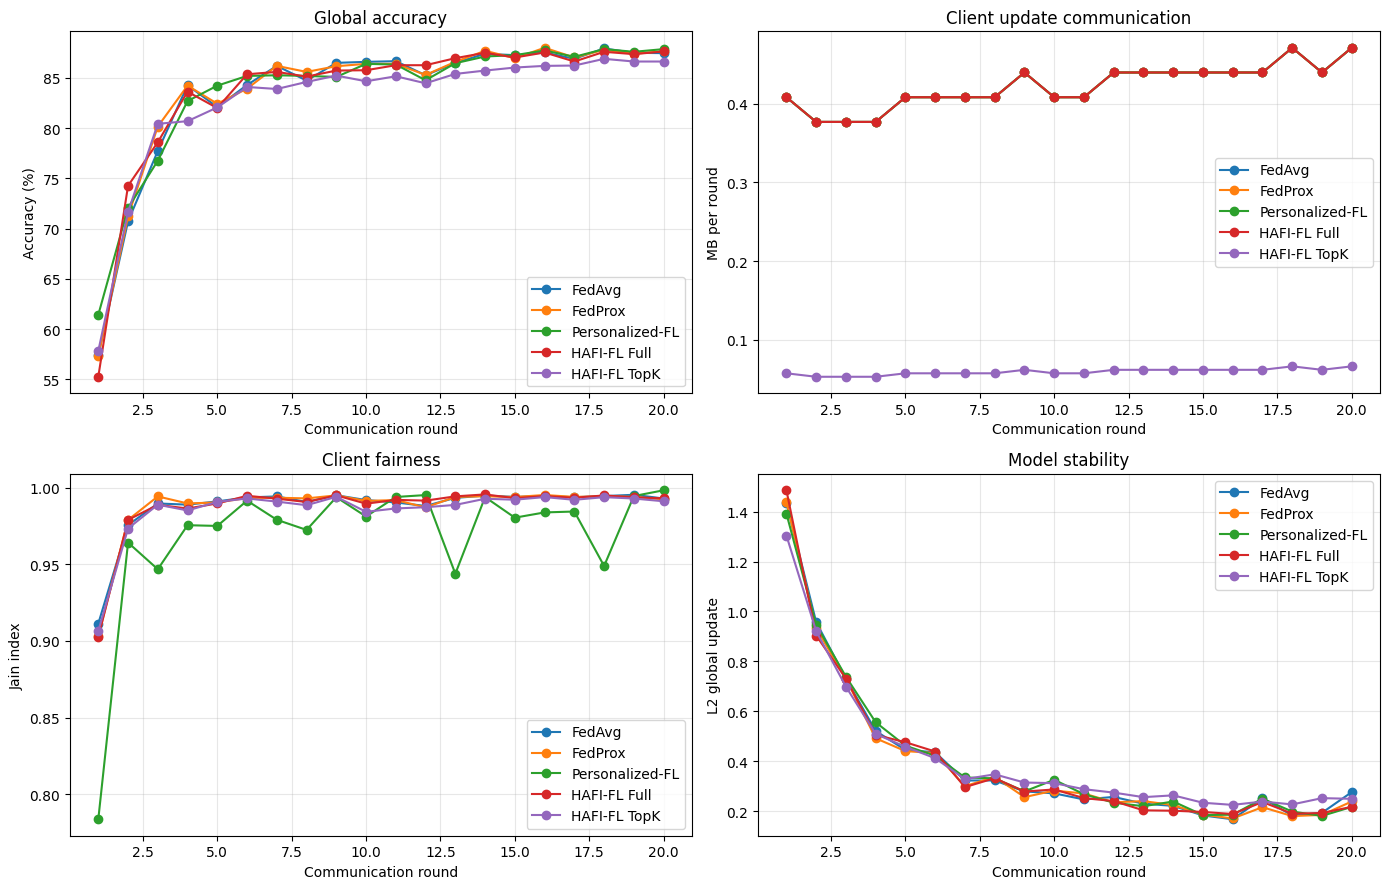

In [10]:
if HAS_MATPLOTLIB:
    def rows_for(name):
        return [r for r in all_records if r["algorithm"] == name]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    for algorithm in ALGORITHMS:
        rows = rows_for(algorithm)
        rounds = [r["round"] for r in rows]
        axes[0, 0].plot(rounds, [100 * r["global_accuracy"] for r in rows], marker="o", label=algorithm)
        axes[0, 1].plot(rounds, [r["communication_mb"] for r in rows], marker="o", label=algorithm)
        axes[1, 0].plot(rounds, [r["fairness_jain"] for r in rows], marker="o", label=algorithm)
        axes[1, 1].plot(rounds, [r["model_stability_l2"] for r in rows], marker="o", label=algorithm)

    axes[0, 0].set_title("Global accuracy")
    axes[0, 0].set_ylabel("Accuracy (%)")
    axes[0, 1].set_title("Client update communication")
    axes[0, 1].set_ylabel("MB per round")
    axes[1, 0].set_title("Client fairness")
    axes[1, 0].set_ylabel("Jain index")
    axes[1, 1].set_title("Model stability")
    axes[1, 1].set_ylabel("L2 global update")

    for ax in axes.ravel():
        ax.set_xlabel("Communication round")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("matplotlib is not installed in this environment. The numeric summary above is still complete.")

## 10. What HAFI-FL Adds Over the Baselines

- Dynamic client participation: each round uses a shared 20-30% dropout
  schedule and gradually onboards clients.
- Decoupled HAFI comparison: HAFI-FL Full tests adaptive hierarchical
  aggregation without compression, while HAFI-FL TopK measures the
  communication-accuracy tradeoff separately.
- Reputation-aware aggregation: HAFI-FL weights clients by reliability,
  contribution, local accuracy, latency, and update-direction diversity
  instead of only sample count.
- Hierarchical 6G edge topology: clients aggregate at edge clusters, then
  regional aggregators, then the global aggregator.
- Late-joiner handling: clients start reputation tracking only after they are
  first eligible, so clients 16-19 are not penalized before onboarding.
- Communication efficiency: HAFI-FL TopK transmits compressed model updates
  and records update payload MB per round.
- Non-IID robustness: clients are split with Dirichlet label skew, so each
  client sees a different class distribution.
- Evaluation metrics: global accuracy, local accuracy, communication cost,
  convergence speed, dropout robustness, scalability indicators, fairness,
  and model stability are collected per round.

To make the experiment heavier, increase train_limit, test_limit, num_rounds,
or reduce dirichlet_alpha for more severe heterogeneity.